## Анализ GRU с вниманием

- [Распределение весов внимания](#распределение-весов-внимания)
- [Распределение всех весов модели](#распределение-всех-весов)
- [Важность признаков](#важность-признаков)

In [1]:
import pandas as pd
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

In [5]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [6]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

In [7]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)  
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)    

In [8]:
def model_analysis(model, total_epochs, model_optimizer, criterion, focal_loss = False):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            if focal_loss == True:
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
                loss = criterion(output, y_one_hot)
            else:
                loss = criterion(output, y_batch)
            
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

In [9]:
attn_model_bidirect = best_model = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.005, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

In [10]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.018786
Epoch 10/40, Loss: 0.952992
Epoch 20/40, Loss: 0.909676
Epoch 30/40, Loss: 0.891848
Epoch 40/40, Loss: 0.858118


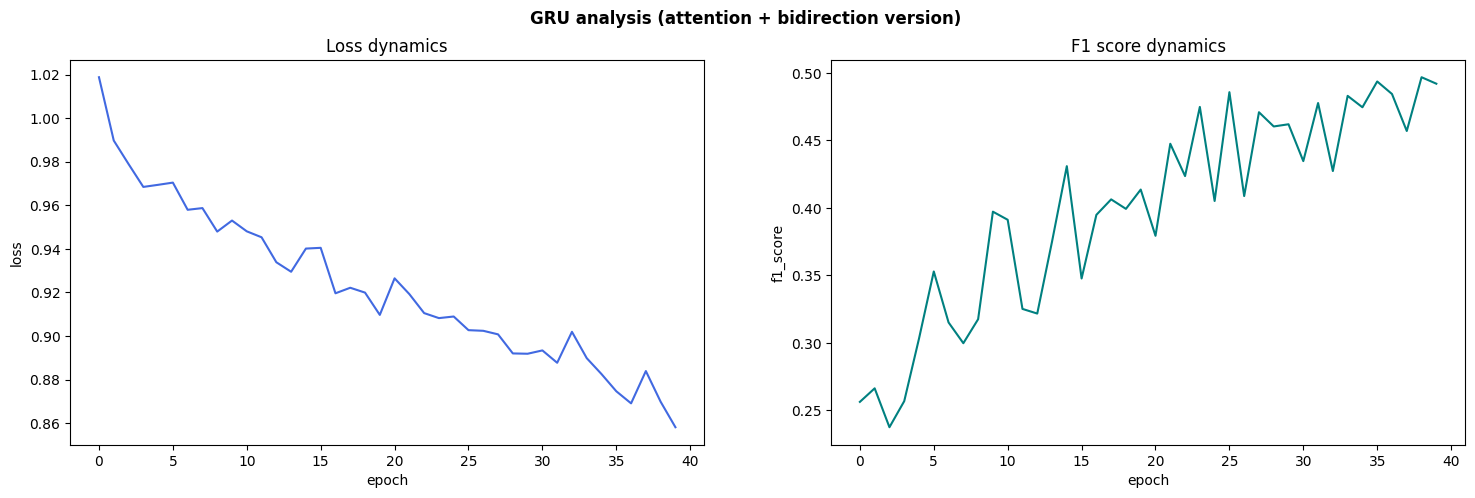

In [11]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

In [12]:
pred = attn_model_bidirect(X_test)      
y_pred = pred.argmax(dim = 1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.44      0.71      0.55        63
    Positive       0.43      0.07      0.12        45
    Negative       0.12      0.12      0.12        25

    accuracy                           0.38       133
   macro avg       0.33      0.30      0.26       133
weighted avg       0.38      0.38      0.32       133



### Распределение весов внимания

In [36]:
def plot_attention(attention_weights, seq_len = 32):
    weights = attention_weights.squeeze(-1).cpu().detach().numpy()
    mean_weights = weights.mean(axis=0)

    clr = plt.cm.coolwarm(np.linspace(0.1, 1.0, len(mean_weights)))
    
    plt.figure(figsize=(7, 5))
    plt.bar(range(len(mean_weights)), mean_weights, color = clr)
    plt.xlabel('position in sequence')
    plt.ylabel('mean weight value')
    plt.title('Attention Weights Distribution', fontweight='bold')
    plt.show()

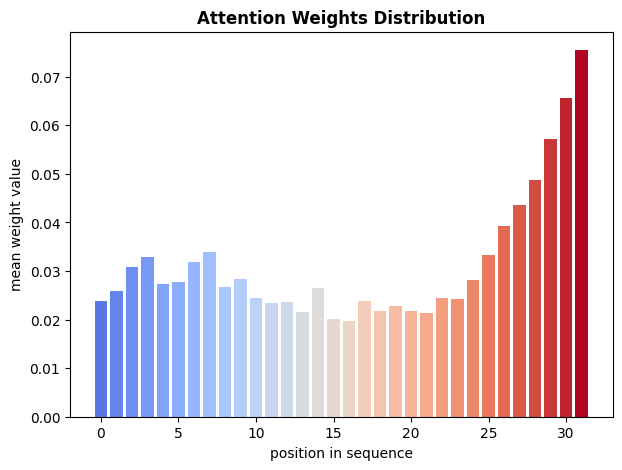

In [37]:
pred, attn_weights = attn_model_bidirect(X_test, return_attention = True)

plot_attention(attn_weights)

### Распределение всех весов

In [38]:
all_weights = []
layer_names = []

for name, param in attn_model_bidirect.named_parameters():
    if 'weight' in name and param.requires_grad:
        weights = param.detach().cpu().numpy().flatten()
        all_weights.append(weights)
        layer_names.append(name)

In [39]:
layer_names

['gru.weight_ih_l0',
 'gru.weight_hh_l0',
 'gru.weight_ih_l0_reverse',
 'gru.weight_hh_l0_reverse',
 'attention.0.weight',
 'fc.weight']

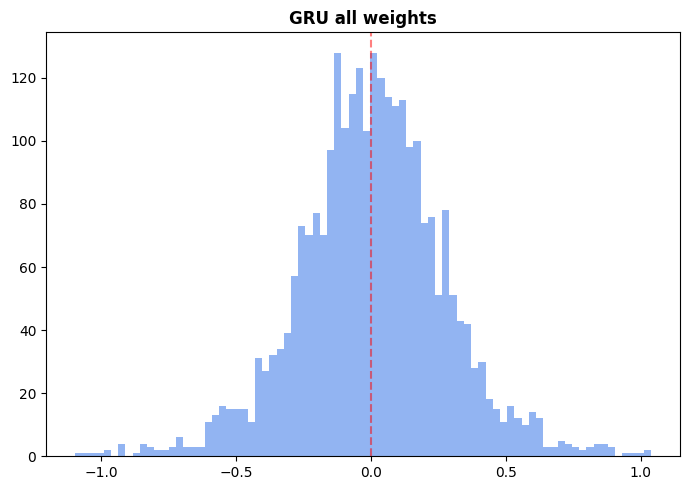

In [40]:
plt.figure(figsize=(7, 5))

weights = np.concatenate(all_weights)
plt.hist(weights, bins = 80, color = 'cornflowerblue', alpha = 0.7)
plt.axvline(x = 0, color = 'red', linestyle = '--', alpha = 0.5)

plt.title('GRU all weights', fontweight='bold')
plt.tight_layout()

### Важность признаков

In [46]:
from sklearn.ensemble import RandomForestClassifier

def analyze_feature_importance(X, y, feature_names):
    X_mean = X.mean(axis = 1) # среднее для каждой последовательности
    
    clf_model = RandomForestClassifier(n_estimators = 100, random_state = 0)
    clf_model.fit(X_mean, y)
    
    importance = clf_model.feature_importances_
    clr = plt.cm.coolwarm(np.linspace(0.1, 1.0, len(importance)))
    
    plt.figure(figsize=(7, 5))
    indices = np.argsort(importance)[::-1]
    plt.bar(range(len(importance)), importance[indices], color = clr)
    plt.xticks(range(len(importance)), [feature_names[i] for i in indices], rotation=45)
    plt.ylabel('importance')
    plt.title('Feature Importance', fontweight='bold')
    plt.show()
    
    return importance

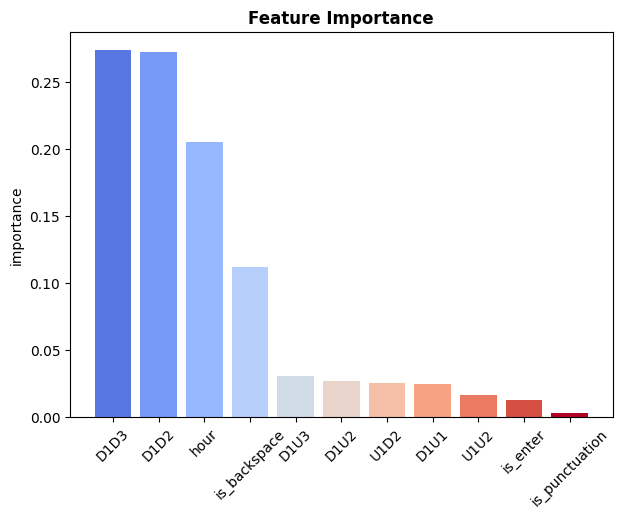

In [47]:
importance = analyze_feature_importance(X_train.numpy(), y_train.numpy(), feature_cols)